In [87]:
import os
import pandas as pd
from openai import OpenAI

import numpy as np
import json
from dotenv import load_dotenv

In [88]:
repo_dir = "/Users/haya1/Documents/LanguageModel_Labels/congressional_bills"
os.chdir(repo_dir)

# Place API_KEY in the .env file
load_dotenv()
api_key = os.environ.get('API_KEY')
client = OpenAI(api_key=api_key)

data_dir = os.path.join(repo_dir, "01_bills")
llm_dir = os.path.join(repo_dir, "02_llm")

In [89]:
bills = pd.read_csv(os.path.join(data_dir, "bills.csv"))[['BillID', 'Major', 'MajorText', 'Description']]

n_examples = 5

# Bills used for few-shot prompting
examples01_path = os.path.join(llm_dir, "examples01.csv")
examples02_path = os.path.join(llm_dir, "examples02.csv")
examples03_path = os.path.join(llm_dir, "examples03.csv")

if not (os.path.exists(examples01_path) and os.path.exists(examples02_path) and os.path.exists(examples03_path)):
    # TODO: add seed for replication
    examples = bills.groupby("Major").sample(n=1, replace=False).sample(n=3*n_examples, replace=False).reset_index(drop=True)
    examples01, examples02, examples03 = np.array_split(examples, 3)
    examples01.to_csv(examples01_path, index=False)
    examples02.to_csv(examples02_path, index=False)
    examples03.to_csv(examples03_path, index=False)
    
    condition = bills["BillID"].apply(lambda x: x not in examples["BillID"].to_list())
    bills_without_examples = bills[condition]
    print(f"Exclude few-shot examples, n = {len(examples)}, from bills data ...")
    bills_without_examples.to_csv(os.path.join(llm_dir, "bills_without_examples.csv"), index=False)
    print(f"bills_without_examples.csv, n = {len(bills_without_examples)}, saved at {llm_dir}")

MAJOR_TEXT = {}
CATEGORIES = ""
for major in bills["Major"].unique(): 
    dict_key = int(major)
    dict_val = bills.loc[bills["Major"]==major, "MajorText"].unique()[0]
    MAJOR_TEXT[dict_key] = dict_val
    CATEGORIES += "%d. %s\n" % (dict_key, dict_val)
    
del bills

## Generate prompts

In [90]:
MODEL = "gpt-3.5-turbo"
TEMPERATURE = 0
USE_JSON = True

QUESTION =f"""Here is a description of a bill introduced in the U.S. Congress:
"{{0}}"

Please classify this description into one of the following categories:
{CATEGORIES}
"""

ANSWER_JSON = f"""
Output a JSON object structured like: {{{{
    "Category": an integer from {min(MAJOR_TEXT.keys())} to {max(MAJOR_TEXT.keys())} of the bill category,
    "Confidence": a number from 0 to 1 with 2 decimal places of your confidence in your bill classification
}}}}"""

ANSWER_JSON_EXPLANATION = f"""
Output a JSON object structured like: {{{{
    "Category": an integer from {min(MAJOR_TEXT.keys())} to {max(MAJOR_TEXT.keys())} of the bill category,
    "Confidence": a number from 0 to 1 with 2 decimal places of your confidence in your bill classification,
    "Explanation": a one-sentence explanation of your bill category answer
}}}}"""

ANSWER_BLANKS = f"""
Write your answer as:
____ (fill in with an integer from {min(MAJOR_TEXT.keys())} to {max(MAJOR_TEXT.keys())} of the bill category),
____ (fill in with a number from 0 to 1 with 2 decimal places of your confidence in your bill classification)
"""

ANSWER_BLANKS_EXPLANATION = f"""
Write your answer as:
____ (fill in with an integer from {min(MAJOR_TEXT.keys())} to {max(MAJOR_TEXT.keys())} of the bill category),
____ (fill in with a number from 0 to 1 with 2 decimal places of your confidence in your bill classification),
____ (fill in with a one-sentence explanation of your bill category answer)
"""

In [91]:
prompting_strategies = pd.DataFrame(data = {
    "PromptingStrategyName": [
        "No Modification", 
        "Persona Modification", "Persona Modification", "Persona Modification", "Persona Modification", 
        "Chain-of-Thoughts Prompting", "Chain-of-Thoughts Prompting", "Chain-of-Thoughts Prompting", 
        "Few-Shot Prompting", "Few-Shot Prompting", "Few-Shot Prompting"
        ],
    "Text": [
        None, 
        "You are a knowledgeable political analyst. ",
        "Answer this question as if you are a political scientist that studies legislation in the United States Congress. ",
        "Answer this question as if you are an expert in United States politics. ",
        "Answer this question as if you were a helpful research assistant for a political scientist. ",
        "Think carefully. ", 
        "Let's think step by step. Lay out each step. ", 
        "Please provide an explanation for your answer. ",
        None, None, None,
        ],
    "TextLocation": [
        None, 
        "before", "before", "before", "before", 
        "after", "after", "after", 
        None, None, None],
    "ExamplesPath": [
        None, 
        None, None, None, None, 
        None, None, None, 
        os.path.join(llm_dir, "examples01.csv"),
        os.path.join(llm_dir, "examples02.csv"),
        os.path.join(llm_dir, "examples03.csv")
    ]
})
prompting_strategies["AddExplanation"] = prompting_strategies["PromptingStrategyName"] == "Chain-of-Thoughts Prompting"
prompting_strategies["AddExamples"] = prompting_strategies["PromptingStrategyName"] == "Few-Shot Prompting"

prompting_strategies = pd.concat([prompting_strategies, prompting_strategies], ignore_index=True)
prompting_strategies["UseJSON"] = [True if i < int(len(prompting_strategies)/2) else False for i in range(len(prompting_strategies))]

prompting_strategies.insert(loc=0, column="PromptingStrategyID", value = list(range(1, len(prompting_strategies)+1)))
prompting_strategies["Model"] = MODEL
prompting_strategies["Temperature"] = TEMPERATURE 
prompting_strategies.to_csv(os.path.join(llm_dir, "prompting_strategies.csv"), index=False)

In [92]:
def create_message_user(strategy):
    if strategy["TextLocation"] == "before":
        question = strategy["Text"] + QUESTION 
    elif strategy["TextLocation"] == "after":
        question = QUESTION + strategy["Text"] + "\n\n"
    else:
        question = QUESTION 

    if strategy["UseJSON"]:
        if strategy["AddExplanation"]:
            answer = ANSWER_JSON_EXPLANATION
        else:
            answer = ANSWER_JSON
    else:
        if strategy["AddExplanation"]:
            answer = ANSWER_BLANKS_EXPLANATION
        else:
            answer = ANSWER_BLANKS
            
    content = question + answer

    return {"role": "user", "content": content}

def create_message_assistant(strategy, category, confidence, explanation=None):
    if strategy["UseJSON"]:
        if strategy["AddExplanation"]:

            if explanation is None:
                raise Exception("AddExplanation=True but explanation=None. You need to pass a string to explanation variable")
            
            correct_answer = {
                "Category": category,
                "Confidence": np.round(confidence, decimals=2),
                "Explanation": explanation
            }
        else:
            correct_answer = {
                "Category": category,
                "Confidence": np.round(confidence, decimals=2)
            }
        content = json.dumps(correct_answer)

    else:
        if strategy["AddExplanation"]:

            if explanation is None:
                raise Exception("AddExplanation=True but explanation=None. You need to pass a string to explanation variable")
            
            correct_answer = "%d, %.2f, %s\n" % (category, confidence, explanation)
        else:
            correct_answer = "%d, %.2f\n" % (category, confidence)
        content = correct_answer
    
    return {"role": "assistant", "content": content}

def create_messages(strategy, min_confidence=0.8, max_confidence=1):
    messages = []

    if strategy["AddExamples"]:
        bills_examples = pd.read_csv(strategy["ExamplesPath"])
        
        for _, bill in bills_examples.iterrows():
            message_user = create_message_user(strategy)
            message_user["content"] = message_user["content"].format(bill["Description"])

            messages.append(message_user)
            messages.append(create_message_assistant(
                strategy,
                category=bill["Major"], 
                confidence=np.random.uniform(min_confidence, max_confidence)
                ))
    
    user_message = create_message_user(strategy)
    messages.append(user_message)
    return messages

prompting_strategies = pd.read_csv(os.path.join(llm_dir, "prompting_strategies.csv"))
prompting_strategies_json = []
for _, strategy in prompting_strategies.iterrows():
    strategy_json = {
        "PromptingStrategyID": strategy["PromptingStrategyID"],
        "PromptingStrategyName": strategy["PromptingStrategyName"],
        "UseJSON": strategy["UseJSON"],
        "AddExplanation": strategy["AddExplanation"],
        "AddExamples": strategy["AddExamples"],
        "Model": strategy["Model"],
        "Temperature": strategy["Temperature"],
        "Messages": create_messages(strategy)
    }
    prompting_strategies_json.append(strategy_json)
    
with open(os.path.join(llm_dir, "prompting_strategies.jsonl"), "w") as f:
    for strategy_json in prompting_strategies_json:
        f.write(json.dumps(strategy_json) + "\n")

In [57]:
from copy import deepcopy

prompting_strategies = pd.read_json(os.path.join(llm_dir, "prompting_strategies.jsonl"), lines=True)
bills = pd.read_csv(os.path.join(llm_dir, "bills_without_examples.csv")).sample(n=2) # TODO: remove .sample(n=2)
id = 0
prompts = []
for _, bill in bills.iterrows():
    for _, strategy in prompting_strategies.iterrows():
        
        # add bill to last used message
        bill_messages = deepcopy(strategy["Messages"])
        bill_messages[-1]["content"] = bill_messages[-1]["content"].format(bill["Description"])
        
        id = id + 1
        prompt = {
            "ID": id,
            "BillID": bill["BillID"],
            "PromptingStrategyID": strategy["PromptingStrategyID"],
            "Description": bill["Description"],
            "PromptingStrategyName": strategy["PromptingStrategyName"],
            "UseJSON": strategy["UseJSON"],
            "AddExplanation": strategy["AddExplanation"],
            "AddExamples": strategy["AddExamples"],
            "Model": strategy["Model"],
            "Temperature": strategy["Temperature"],
            "Major": bill["Major"],
            "MajorText": bill["MajorText"],
            "Messages": bill_messages
        }
        prompts.append(prompt)

with open(os.path.join(llm_dir, "prompts.jsonl"), "w") as f:
    for prompt in prompts:
        f.write(json.dumps(prompt) + "\n")

## Generate responses

In [20]:
# define a response function that gives us the LLM's response to a user prompt
# import warnings
def query_llm(prompt):
    response_text = client.chat.completions.create(
        model = prompt["Model"],
        temperature = prompt["Temperature"],
        response_format = {"type": "json_object"} if prompt["UseJSON"] else None,
        messages = prompt["Messages"],
        logprobs = True,
        n = 1 # num_responses
    ).choices[0].message.content
    
    if prompt["UseJSON"]:
        temp = json.loads(response_text)
        response_json = {
            "ID": prompt["ID"],
            "MajorLLM": int(temp["Category"]),
            "ConfidenceLLM": float(temp["Confidence"]),
            "ExplanationLLM": temp["Explanation"] if prompt["AddExplanation"] else None
        }

    else:
        pattern = r'^(\d+)\s*,\s*([\d\.]+)\s*,?\s*(.*)?$'
        match = re.match(pattern, response_text.replace('\n', ' '))
        # if match:
        response_json = {
            "ID": prompt["ID"],
            "MajorLLM": int(match.group(1)),
            "ConfidenceLLM": float(match.group(2)),
            "ExplanationLLM": match.group(3) if prompt["AddExplanation"] else None
        }
        # else:
        #     raise ValueError(f"String format is incorrect for ID: {prompt['ID']}")
            
    return response_json

In [60]:
from tqdm import tqdm 
import re

prompts = pd.read_json(os.path.join(llm_dir, "prompts.jsonl"), lines=True).sample(n=2)
print(f"Loaded prompts data, n = {len(prompts)}")

responses = []
for _, prompt in tqdm(prompts.iterrows(), total=len(prompts)):
    responses.append(query_llm(prompt))

with open(os.path.join(llm_dir, "responses.jsonl"), "w") as f:
    for response in responses:
        f.write(json.dumps(response) + "\n")

Loaded prompts data, n = 2


100%|██████████| 2/2 [00:01<00:00,  1.55it/s]


In [71]:
# Merge prompts and responses datasets
prompts = pd.read_json(os.path.join(llm_dir, "prompts.jsonl"), lines=True)
prompts.drop(columns="Messages", inplace=True)

responses = pd.read_json(os.path.join(llm_dir, "responses.jsonl"), lines=True)
responses.insert(loc=2, column="MajorTextLLM", value=responses["MajorLLM"].apply(lambda x: MAJOR_TEXT[x]))

prompts_and_responses = prompts.merge(responses, left_on="ID", right_on="ID")
print(f"Merged prompts and responses data, n = {len(prompts_and_responses)}")
prompts_and_responses

Merged prompts and responses data, n = 2


,ID,BillID,PromptingStrategyID,Description,PromptingStrategyName,UseJSON,AddExplanation,AddExamples,Model,Temperature,Major,MajorText,MajorLLM,MajorTextLLM,ConfidenceLLM,ExplanationLLM
0,5,105-HR-2600,5,To amend title XVIII of the Social Security Ac...,Persona Modification,True,False,False,gpt-3.5-turbo,0,3,Health,3,Health,0.85,None
1,19,105-HR-2600,19,To amend title XVIII of the Social Security Ac...,Chain-of-Thoughts Prompting,False,True,False,gpt-3.5-turbo,0,3,Health,12,Social Welfare,0.90,The bill focuses on healthcare policy related ...


## Unique MajorLLM

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

repo_dir = "/Users/haya1/Documents/LanguageModel_Labels/congressional_bills"
responses = pd.read_csv(os.path.join(repo_dir, "02_llm/responses.csv"))
print(f"Loaded responses.csv data, n = {len(responses)}")
print(f"Number of bills = {len(responses['BillID'].unique())}")
print(f"Number of prompting strategies per bill = {len(responses['StrategyID'].unique())}")
print(f"Number of Major topic IDs = {len(responses['Major'].unique())}")

Loaded responses.csv data, n = 1100
Number of bills = 100
Number of prompting strategies per bill = 11
Number of Major topic IDs = 20


In [195]:
unique_MajorLLM = responses.groupby(["BillID"]).agg(
    unique_count = ('MajorLLM','nunique')
    ).reset_index()

labels, counts = np.unique(unique_MajorLLM["unique_count"], return_counts=True)
plt.bar(labels, counts, align='center')
plt.gca().set_xticks(labels)
plt.title('Histogram of unique MajorLLM from 11 prompting strategies across 100 bills')
plt.xlabel('Number of unique MajorLLM')
plt.ylabel('Number of Bills')
plt.show()

,BillID,unique_count
0,100-HR-2613,2
1,100-HR-344,1
2,100-HR-3868,3
3,101-HR-1972,3
4,101-HR-2762,2
...,...,...
95,97-S-88,1
96,98-HR-3602,1
97,98-HR-5887,2
98,98-S-2025,1


/var/folders/66/slx_tnrd6m52p5pn74lh2h540000gn/T/ipykernel_91993/3422338739.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correct_MajorLLM = responses.groupby(["StrategyID"]).apply(major_accuracy).reset_index()


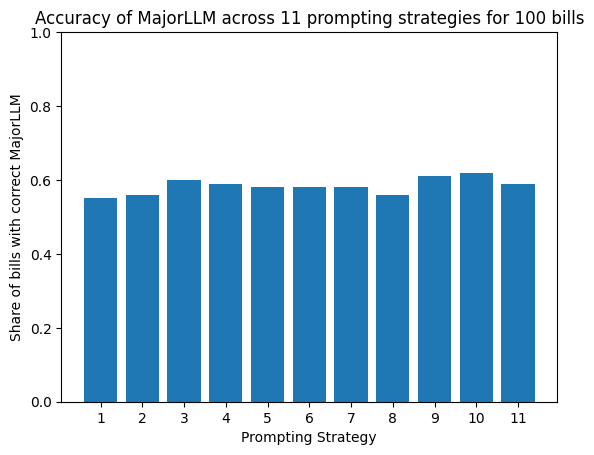

In [12]:
def major_accuracy(group):
    total = len(group)
    equal_count = (group['Major'] == group['MajorLLM']).mean()
    not_equal_count = total - equal_count
    return pd.Series({
        'share_correct_MajorLLM': (group['Major'] == group['MajorLLM']).mean(),
    })

correct_MajorLLM = responses.groupby(["StrategyID"]).apply(major_accuracy).reset_index()
# labels, counts = np.unique(unique_MajorLLM["unique_count"], return_counts=True)
plt.bar(correct_MajorLLM["StrategyID"], correct_MajorLLM["share_correct_MajorLLM"], align='center')
plt.gca().set_xticks(correct_MajorLLM["StrategyID"])
plt.title('Accuracy of MajorLLM across 11 prompting strategies for 100 bills')
plt.xlabel('Prompting Strategy')
plt.ylabel('Share of bills with correct MajorLLM')
plt.ylim((0,1))
plt.show()
